# Classificação de Tumores Cerebrais em Imagens de Ressonância Magnética

**Projeto Prático de Inteligência Artificial — 2026**

Este notebook implementa **oito experimentos completos** para classificar imagens de ressonância magnética cerebral nas classes:

- `glioma`;
- `meningioma`;
- `notumor`;
- `pituitary`.

## Experimentos

| Experimento | Técnica | Alteração principal |
|---:|---|---|
| 1 | CNN | Modelo básico, sem regularização |
| 2 | CNN | Dropout de 20% |
| 3 | CNN | Dropout de 50% e Batch Normalization |
| 4 | CNN | Data augmentation, regularização L2 e Early Stopping |
| 5 | SVM | Kernel linear e `C=1` |
| 6 | SVM | Kernel RBF, `C=1` e `gamma="scale"` |
| 7 | SVM | Kernel RBF, `C=10` e `gamma="scale"` |
| 8 | SVM | Kernel RBF, PCA e `class_weight="balanced"` |

## Métricas avaliadas

- acurácia;
- precisão macro e weighted;
- recall macro e weighted;
- F1-Score macro e weighted;
- matriz de confusão;
- métricas por classe;
- quantidade de tumores classificados incorretamente como `notumor`.

> Este projeto possui finalidade exclusivamente acadêmica e não deve ser utilizado para diagnóstico médico.

## 1. Preparação do Google Colab

Antes da execução, selecione:

`Ambiente de execução → Alterar o tipo de ambiente de execução → GPU`

A GPU acelera as CNNs. Os experimentos com SVM são executados principalmente na CPU.

In [ ]:
!pip install -q --upgrade kagglehub scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 94.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


## 2. Importações

In [ ]:
from pathlib import Path
import gc
import json
import random
import shutil
import time
import warnings

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image
from IPython.display import display
from tqdm.auto import tqdm

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from skimage.feature import hog

warnings.filterwarnings("ignore")

## 3. Configurações gerais

Por padrão, o notebook executa o conjunto completo.

Para testar rapidamente se todas as células funcionam antes do treinamento integral, altere `FAST_MODE` para `True`. Os resultados do modo rápido **não devem ser usados no relatório final**.

In [ ]:
SEED = 42
FAST_MODE = False

IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32
VALIDATION_SIZE = 0.20

CNN_EPOCHS = 15
CNN_EXP4_MAX_EPOCHS = 25

SVM_IMG_SIZE = (64, 64)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

CLASSES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]

CLASS_TO_INDEX = {
    classe: indice
    for indice, classe in enumerate(CLASSES)
}

RESULTS_DIR = Path("/content/brain_tumor_results")
MODELS_DIR = RESULTS_DIR / "modelos"
REPORTS_DIR = RESULTS_DIR / "relatorios_classificacao"
CONFUSION_DIR = RESULTS_DIR / "matrizes_confusao"
HISTORY_DIR = RESULTS_DIR / "historicos"

for pasta in [
    RESULTS_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    CONFUSION_DIR,
    HISTORY_DIR,
]:
    pasta.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))
print("Modo rápido:", FAST_MODE)
print("Pasta de resultados:", RESULTS_DIR)

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Modo rápido: False
Pasta de resultados: /content/brain_tumor_results


## 4. Download do dataset com KaggleHub

In [ ]:
DATASET_HANDLE = "masoudnickparvar/brain-tumor-mri-dataset"

dataset_path = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

print("Dataset disponível em:")
print(dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset disponível em:
/kaggle/input/brain-tumor-mri-dataset


## 5. Localização automática das pastas

In [ ]:
def encontrar_pasta(raiz: Path, nome: str) -> Path:
    resultados = [
        caminho
        for caminho in raiz.rglob("*")
        if caminho.is_dir()
        and caminho.name.lower() == nome.lower()
    ]

    if not resultados:
        raise FileNotFoundError(
            f"A pasta '{nome}' não foi encontrada em '{raiz}'."
        )

    return resultados[0]


training_dir = encontrar_pasta(dataset_path, "Training")
testing_dir = encontrar_pasta(dataset_path, "Testing")

print("Treinamento:", training_dir)
print("Teste:", testing_dir)

Treinamento: /kaggle/input/brain-tumor-mri-dataset/Training
Teste: /kaggle/input/brain-tumor-mri-dataset/Testing


## 6. Criação do catálogo de imagens

In [ ]:
EXTENSOES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}


def criar_catalogo(diretorio: Path, conjunto: str) -> pd.DataFrame:
    registros = []

    for classe in CLASSES:
        pasta_classe = diretorio / classe

        if not pasta_classe.exists():
            raise FileNotFoundError(
                f"Classe não encontrada: {pasta_classe}"
            )

        arquivos = sorted([
            arquivo
            for arquivo in pasta_classe.rglob("*")
            if arquivo.is_file()
            and arquivo.suffix.lower() in EXTENSOES_VALIDAS
        ])

        for arquivo in arquivos:
            registros.append({
                "path": str(arquivo),
                "classe": classe,
                "label": CLASS_TO_INDEX[classe],
                "conjunto": conjunto,
            })

    return pd.DataFrame(registros)


training_full_df = criar_catalogo(
    training_dir,
    conjunto="Training",
)

test_df = criar_catalogo(
    testing_dir,
    conjunto="Testing",
)

print("Imagens na pasta Training:", len(training_full_df))
print("Imagens na pasta Testing:", len(test_df))

display(training_full_df.head())

Imagens na pasta Training: 5600
Imagens na pasta Testing: 1600


,path,classe,label,conjunto
0,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,0,Training
1,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,0,Training
2,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,0,Training
3,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,0,Training
4,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,0,Training


## 7. Divisão estratificada entre treinamento e validação

A pasta oficial `Testing` permanece completamente separada.

A divisão entre treinamento e validação é estratificada, preservando aproximadamente a proporção das classes.

In [ ]:
train_df, val_df = train_test_split(
    training_full_df,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=training_full_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

if FAST_MODE:
    def amostra_estratificada(
        dataframe: pd.DataFrame,
        tamanho: int,
    ) -> pd.DataFrame:
        tamanho = min(tamanho, len(dataframe))

        amostra, _ = train_test_split(
            dataframe,
            train_size=tamanho,
            random_state=SEED,
            stratify=dataframe["label"],
        )

        return amostra.reset_index(drop=True)

    train_df = amostra_estratificada(train_df, 800)
    val_df = amostra_estratificada(val_df, 240)
    test_df = amostra_estratificada(test_df, 320)

print("Treinamento:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Treinamento: 4480
Validação: 1120
Teste: 1600


## 8. Distribuição das classes

,divisao,classe,quantidade
0,Teste,glioma,400
1,Teste,meningioma,400
2,Teste,notumor,400
3,Teste,pituitary,400
4,Treinamento,glioma,1120
5,Treinamento,meningioma,1120
6,Treinamento,notumor,1120
7,Treinamento,pituitary,1120
8,Validação,glioma,280
9,Validação,meningioma,280


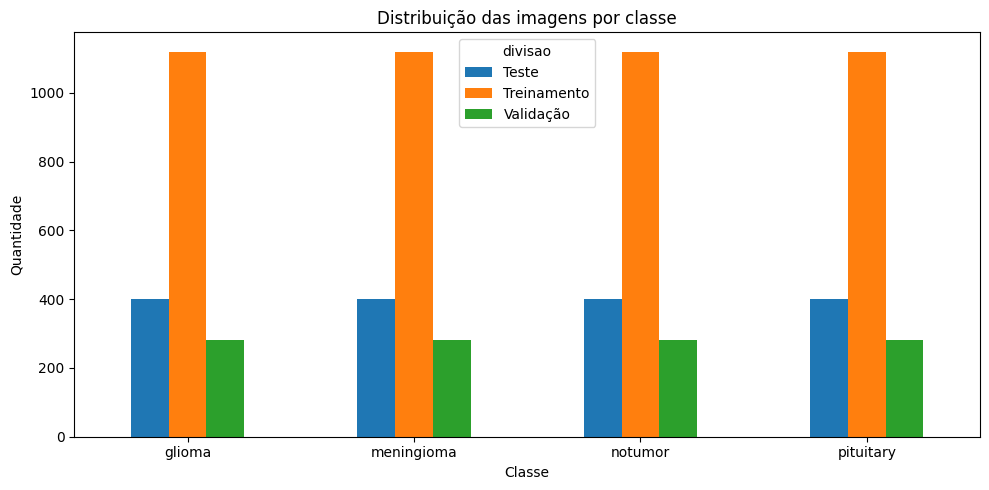

In [ ]:
distribuicao_df = pd.concat(
    [
        train_df.assign(divisao="Treinamento"),
        val_df.assign(divisao="Validação"),
        test_df.assign(divisao="Teste"),
    ],
    ignore_index=True,
)

tabela_distribuicao = (
    distribuicao_df
    .groupby(["divisao", "classe"])
    .size()
    .reset_index(name="quantidade")
)

display(tabela_distribuicao)

grafico_distribuicao = tabela_distribuicao.pivot(
    index="classe",
    columns="divisao",
    values="quantidade",
)

grafico_distribuicao.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Distribuição das imagens por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Exemplos de imagens

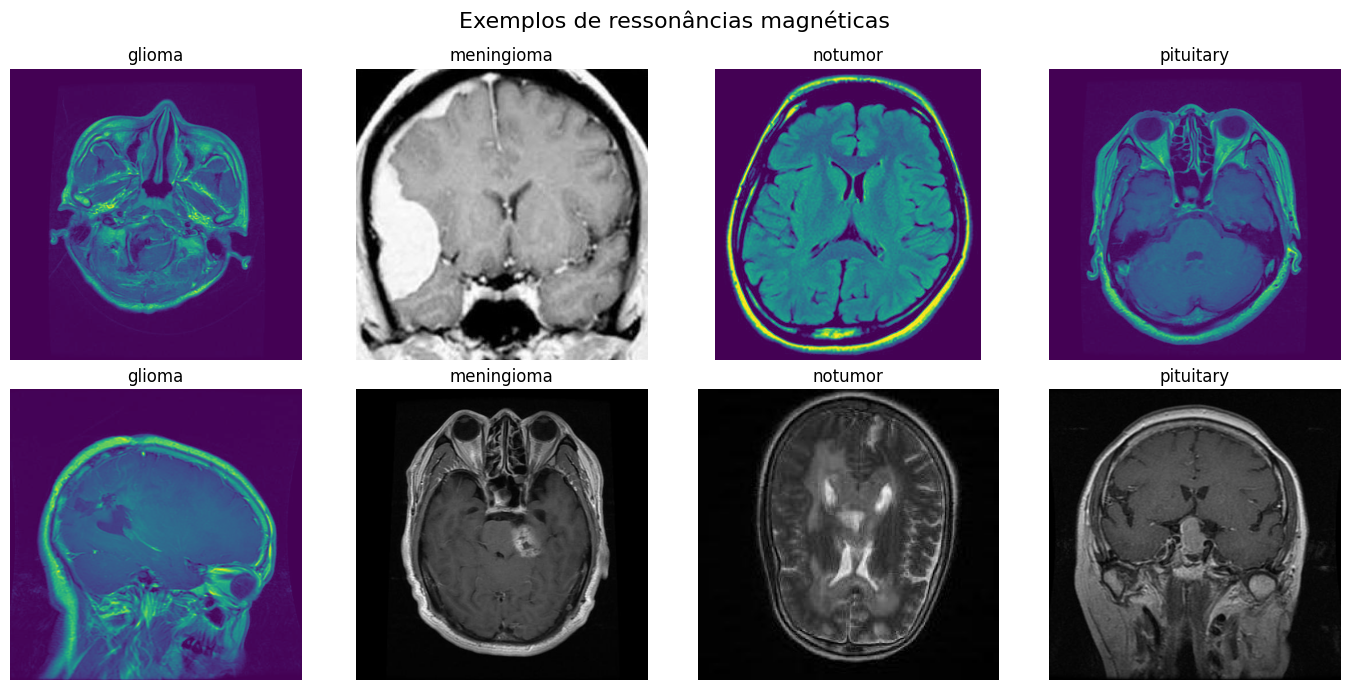

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(CLASSES),
    figsize=(14, 7),
)

for coluna, classe in enumerate(CLASSES):
    amostra_classe = train_df[
        train_df["classe"] == classe
    ].sample(
        n=2,
        random_state=SEED,
    )

    for linha, caminho in enumerate(amostra_classe["path"]):
        with Image.open(caminho) as imagem:
            axes[linha, coluna].imshow(imagem)

        axes[linha, coluna].set_title(classe)
        axes[linha, coluna].axis("off")

plt.suptitle(
    "Exemplos de ressonâncias magnéticas",
    fontsize=16,
)

plt.tight_layout()
plt.show()

# Pipeline TensorFlow para as CNNs

## 10. Leitura e redimensionamento das imagens

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def carregar_imagem_tf(
    caminho: tf.Tensor,
    rotulo: tf.Tensor,
):
    dados = tf.io.read_file(caminho)

    imagem = tf.io.decode_image(
        dados,
        channels=3,
        expand_animations=False,
    )

    imagem.set_shape([None, None, 3])

    imagem = tf.image.resize(
        imagem,
        IMG_SIZE,
    )

    imagem = tf.cast(
        imagem,
        tf.float32,
    )

    return imagem, rotulo


def criar_dataset_tf(
    dataframe: pd.DataFrame,
    treinamento: bool,
) -> tf.data.Dataset:
    caminhos = dataframe["path"].astype(str).to_numpy()
    rotulos = dataframe["label"].astype(np.int32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (caminhos, rotulos)
    )

    if treinamento:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        carregar_imagem_tf,
        num_parallel_calls=AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = criar_dataset_tf(
    train_df,
    treinamento=True,
)

val_ds = criar_dataset_tf(
    val_df,
    treinamento=False,
)

test_ds = criar_dataset_tf(
    test_df,
    treinamento=False,
)

y_test = test_df["label"].to_numpy()

for imagens, rotulos in train_ds.take(1):
    print("Imagens:", imagens.shape)
    print("Rótulos:", rotulos.shape)
    print("Pixels mínimos:", float(tf.reduce_min(imagens)))
    print("Pixels máximos:", float(tf.reduce_max(imagens)))

Imagens: (32, 128, 128, 3)
Rótulos: (32,)
Pixels mínimos: 0.0
Pixels máximos: 255.0


# Funções de avaliação e registro

Todos os experimentos serão avaliados com exatamente as mesmas funções.

In [ ]:
resultados = []
relatorios_por_experimento = {}
matrizes_por_experimento = {}
historicos_cnn = {}


def nome_seguro(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    return texto.strip("_")


def registrar_resultado(registro: dict) -> None:
    global resultados

    resultados = [
        item
        for item in resultados
        if item["experimento"] != registro["experimento"]
    ]

    resultados.append(registro)
    resultados.sort(
        key=lambda item: item["experimento"]
    )


def calcular_metricas(
    y_real: np.ndarray,
    y_predito: np.ndarray,
):
    relatorio = classification_report(
        y_real,
        y_predito,
        labels=list(range(len(CLASSES))),
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    matriz = confusion_matrix(
        y_real,
        y_predito,
        labels=list(range(len(CLASSES))),
    )

    indice_notumor = CLASS_TO_INDEX["notumor"]

    tumores_como_sem_tumor = int(sum(
        matriz[indice_real, indice_notumor]
        for indice_real in range(len(CLASSES))
        if indice_real != indice_notumor
    ))

    metricas = {
        "acuracia": accuracy_score(
            y_real,
            y_predito,
        ),
        "precisao_macro": precision_score(
            y_real,
            y_predito,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            y_real,
            y_predito,
            average="macro",
            zero_division=0,
        ),
        "f1_macro": f1_score(
            y_real,
            y_predito,
            average="macro",
            zero_division=0,
        ),
        "precisao_weighted": precision_score(
            y_real,
            y_predito,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_real,
            y_predito,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(
            y_real,
            y_predito,
            average="weighted",
            zero_division=0,
        ),
        "tumores_como_notumor": tumores_como_sem_tumor,
    }

    relatorio_df = (
        pd.DataFrame(relatorio)
        .transpose()
        .reset_index()
        .rename(columns={"index": "classe"})
    )

    return metricas, relatorio_df, matriz


def salvar_matriz_confusao(
    matriz: np.ndarray,
    experimento: int,
    titulo: str,
):
    visualizacao = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=CLASSES,
    )

    fig, ax = plt.subplots(
        figsize=(8, 8),
    )

    visualizacao.plot(
        ax=ax,
        values_format="d",
    )

    plt.title(titulo)
    plt.xticks(rotation=30)
    plt.tight_layout()

    caminho = (
        CONFUSION_DIR
        / f"experimento_{experimento:02d}.png"
    )

    plt.savefig(
        caminho,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


def exibir_metricas(metricas: dict) -> None:
    print(f"Acurácia:          {metricas['acuracia']:.4f}")
    print(f"Precisão macro:    {metricas['precisao_macro']:.4f}")
    print(f"Recall macro:      {metricas['recall_macro']:.4f}")
    print(f"F1-Score macro:    {metricas['f1_macro']:.4f}")
    print()
    print(f"Precisão weighted: {metricas['precisao_weighted']:.4f}")
    print(f"Recall weighted:   {metricas['recall_weighted']:.4f}")
    print(f"F1 weighted:       {metricas['f1_weighted']:.4f}")
    print()
    print(
        "Tumores classificados como 'notumor':",
        metricas["tumores_como_notumor"],
    )

In [ ]:
import re

## 11. Funções para curvas e execução das CNNs

In [ ]:
def plotar_historico(
    historico,
    experimento: int,
):
    history = historico.history

    plt.figure(figsize=(9, 5))
    plt.plot(
        history["accuracy"],
        label="Treinamento",
    )
    plt.plot(
        history["val_accuracy"],
        label="Validação",
    )
    plt.title(
        f"Experimento {experimento} — Acurácia"
    )
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(
        history["loss"],
        label="Treinamento",
    )
    plt.plot(
        history["val_loss"],
        label="Validação",
    )
    plt.title(
        f"Experimento {experimento} — Loss"
    )
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def executar_experimento_cnn(
    experimento: int,
    nome: str,
    configuracao: str,
    construir_modelo,
    epochs: int,
    callbacks=None,
):
    tf.keras.backend.clear_session()
    gc.collect()

    modelo = construir_modelo()

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001,
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    print(modelo.summary())

    inicio = time.time()

    historico = modelo.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks or [],
        verbose=1,
    )

    tempo_segundos = time.time() - inicio

    loss_teste, acuracia_keras = modelo.evaluate(
        test_ds,
        verbose=1,
    )

    probabilidades = modelo.predict(
        test_ds,
        verbose=1,
    )

    y_predito = np.argmax(
        probabilidades,
        axis=1,
    )

    metricas, relatorio_df, matriz = calcular_metricas(
        y_test,
        y_predito,
    )

    melhor_val_accuracy = float(max(
        historico.history["val_accuracy"]
    ))

    melhor_val_loss = float(min(
        historico.history["val_loss"]
    ))

    registro = {
        "experimento": experimento,
        "tecnica": "CNN",
        "modelo": nome,
        "configuracao": configuracao,
        "val_accuracy": melhor_val_accuracy,
        "val_loss": melhor_val_loss,
        "test_loss": float(loss_teste),
        **metricas,
        "tempo_segundos": tempo_segundos,
        "epocas_executadas": len(
            historico.history["loss"]
        ),
    }

    registrar_resultado(registro)

    relatorios_por_experimento[
        experimento
    ] = relatorio_df

    matrizes_por_experimento[
        experimento
    ] = matriz

    historicos_cnn[
        experimento
    ] = historico.history

    nome_arquivo = nome_seguro(nome)

    modelo.save(
        MODELS_DIR
        / f"experimento_{experimento:02d}_{nome_arquivo}.keras"
    )

    pd.DataFrame(
        historico.history
    ).to_csv(
        HISTORY_DIR
        / f"experimento_{experimento:02d}_historico.csv",
        index=False,
    )

    relatorio_df.to_csv(
        REPORTS_DIR
        / f"experimento_{experimento:02d}.csv",
        index=False,
    )

    plotar_historico(
        historico,
        experimento,
    )

    salvar_matriz_confusao(
        matriz,
        experimento,
        f"Matriz de confusão — Experimento {experimento}",
    )

    exibir_metricas(metricas)

    print(
        f"Tempo de treinamento: "
        f"{tempo_segundos / 60:.2f} minutos"
    )

    return modelo

# Experimento 1 — CNN básica

Modelo de referência, sem dropout, Batch Normalization, L1, L2 ou data augmentation.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - accuracy: 0.4288 - loss: 1.1675 - val_accuracy: 0.5902 - val_loss: 1.0037
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.6196 - loss: 0.9295 - val_accuracy: 0.6536 - val_loss: 0.8360
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.6790 - loss: 0.8202 - val_accuracy: 0.6929 - val_loss: 0.7437
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.7203 - loss: 0.7137 - val_accuracy: 0.7018 - val_loss: 0.7167
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.7467 - loss: 0.6497 - val_accuracy: 0.7384 - val_loss: 0.6254
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.7721 - loss: 0.6041 - val_accuracy: 0.7732 - val_loss: 0.5704
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7855 - loss: 0.5576 - val_accuracy: 0.7759 - val_loss: 0.5771
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7915 - loss: 0.5422 - v

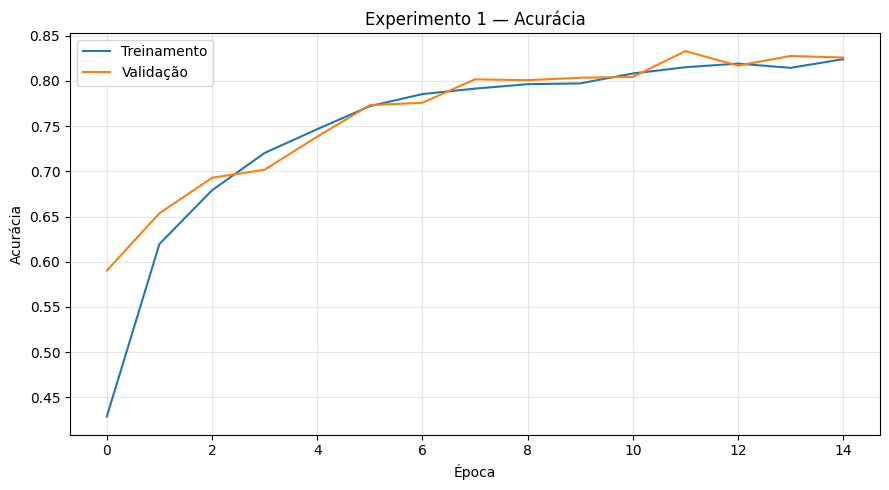

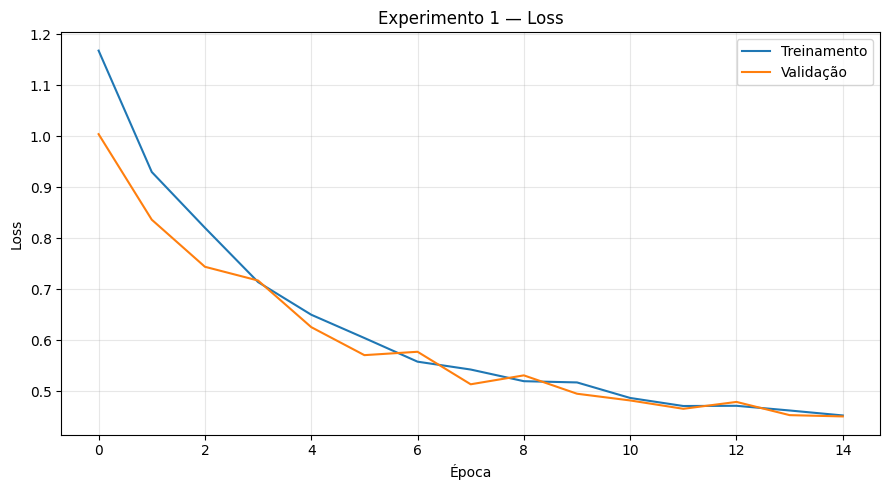

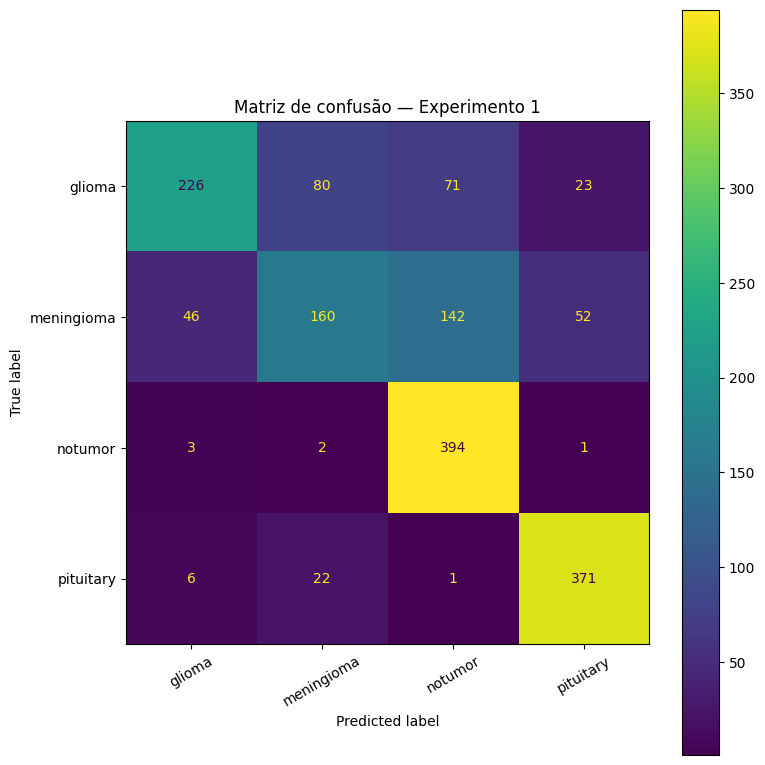

Acurácia:          0.7194
Precisão macro:    0.7221
Recall macro:      0.7194
F1-Score macro:    0.7009

Precisão weighted: 0.7221
Recall weighted:   0.7194
F1 weighted:       0.7009

Tumores classificados como 'notumor': 214
Tempo de treinamento: 2.15 minutos


In [ ]:
def construir_cnn_experimento_1():
    return tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        ),
        tf.keras.layers.Rescaling(1.0 / 255),

        tf.keras.layers.Conv2D(
            32,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            64,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            128,
            activation="relu",
        ),

        tf.keras.layers.Dense(
            len(CLASSES),
            activation="softmax",
            dtype="float32",
        ),
    ])


modelo_exp_1 = executar_experimento_cnn(
    experimento=1,
    nome="CNN básica",
    configuracao=(
        "Filtros 32/64/128; Dense 128; "
        "sem regularização"
    ),
    construir_modelo=construir_cnn_experimento_1,
    epochs=5 if FAST_MODE else CNN_EPOCHS,
)

# Experimento 2 — CNN com Dropout de 20%

A arquitetura básica é mantida, mas uma camada `Dropout(0.20)` é adicionada após a camada densa.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4475 - loss: 1.1406 - val_accuracy: 0.6125 - val_loss: 0.9401
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6112 - loss: 0.9210 - val_accuracy: 0.6866 - val_loss: 0.8215
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.6627 - loss: 0.8089 - val_accuracy: 0.6929 - val_loss: 0.7101
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7056 - loss: 0.7111 - val_accuracy: 0.7688 - val_loss: 0.6847
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.7270 - loss: 0.6569 - val_accuracy: 0.7696 - val_loss: 0.5995
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.7603 - loss: 0.5986 - val_accuracy: 0.7759 - val_loss: 0.5469
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7647 - loss: 0.5785 - val_accuracy: 0.7705 - val_loss: 0.5885
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.7741 - loss: 0.5706 - 

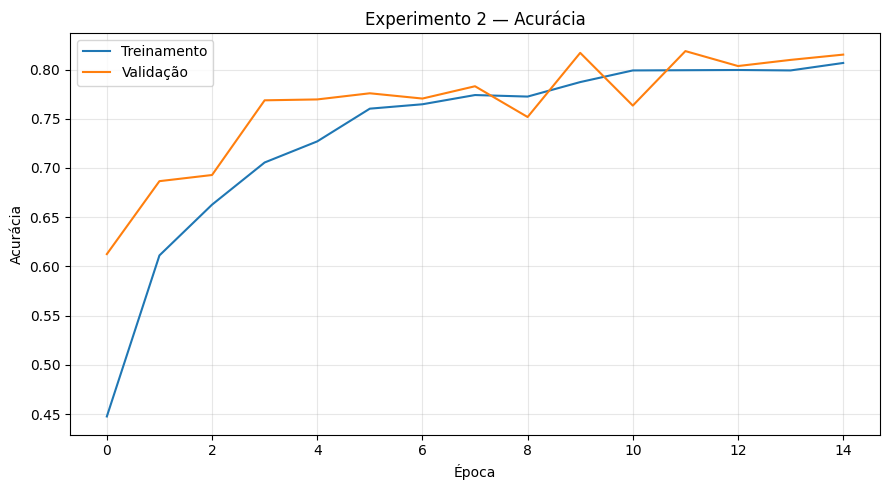

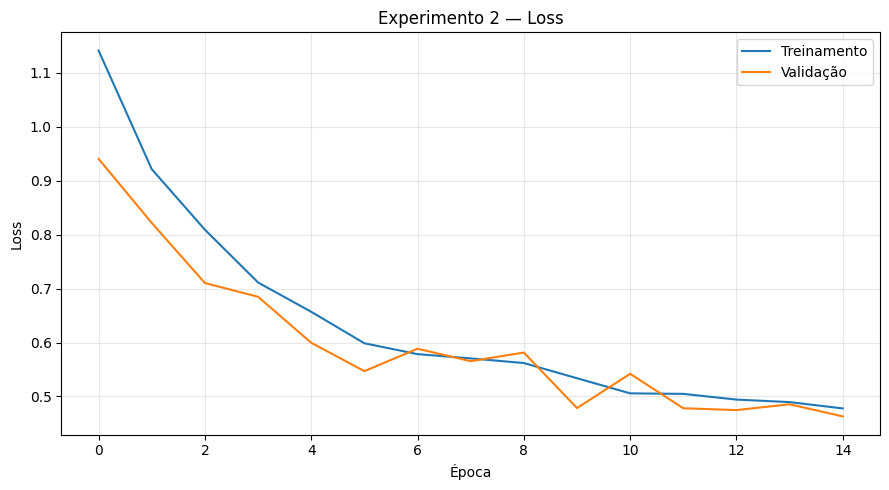

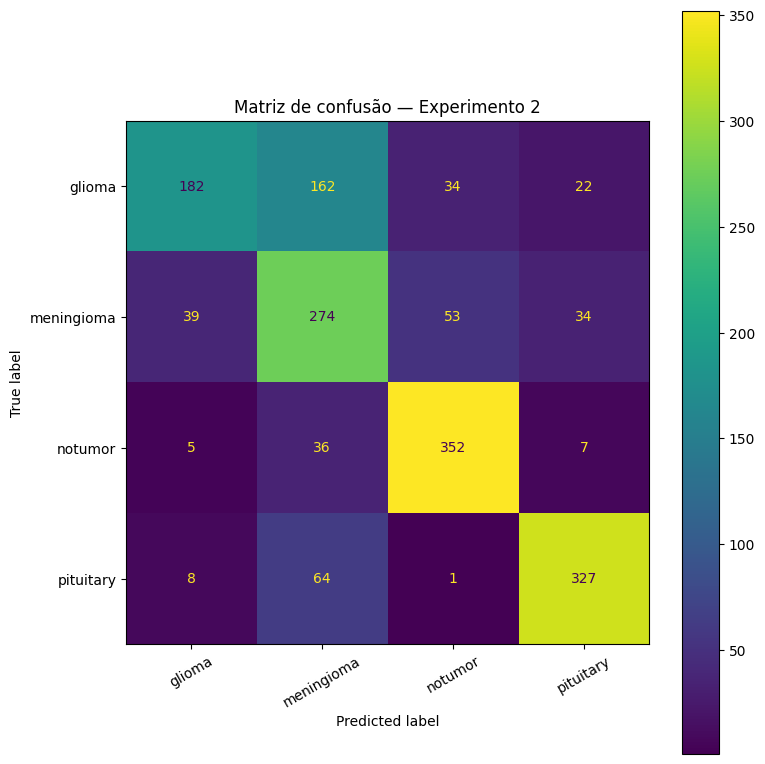

Acurácia:          0.7094
Precisão macro:    0.7319
Recall macro:      0.7094
F1-Score macro:    0.7064

Precisão weighted: 0.7319
Recall weighted:   0.7094
F1 weighted:       0.7064

Tumores classificados como 'notumor': 88
Tempo de treinamento: 1.98 minutos


In [ ]:
def construir_cnn_experimento_2():
    return tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        ),
        tf.keras.layers.Rescaling(1.0 / 255),

        tf.keras.layers.Conv2D(
            32,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            64,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu",
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            128,
            activation="relu",
        ),

        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Dense(
            len(CLASSES),
            activation="softmax",
            dtype="float32",
        ),
    ])


modelo_exp_2 = executar_experimento_cnn(
    experimento=2,
    nome="CNN com Dropout 20%",
    configuracao=(
        "Mesma CNN básica; Dropout 0.20 "
        "após a camada densa"
    ),
    construir_modelo=construir_cnn_experimento_2,
    epochs=5 if FAST_MODE else CNN_EPOCHS,
)

# Experimento 3 — CNN com Batch Normalization e Dropout de 50%

As camadas de Batch Normalization estabilizam as ativações. O Dropout de 50% aplica uma regularização mais forte à camada densa.

Model: "cnn_batchnorm_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,332 (434.89 KB)

 Trainable params: 110,628 (432.14 KB)

 Non-trainable params: 704 (2.75 KB)

None
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.6714 - loss: 0.8348 - val_accuracy: 0.2500 - val_loss: 2.9972
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7511 - loss: 0.6446 - val_accuracy: 0.2920 - val_loss: 2.1521
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8009 - loss: 0.5372 - val_accuracy: 0.5366 - val_loss: 1.2724
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8172 - loss: 0.4807 - val_accuracy: 0.5580 - val_loss: 2.0646
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8333 - loss: 0.4477 - val_accuracy: 0.4929 - val_loss: 2.6850
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8513 - loss: 0.4131 - val_accuracy: 0.5518 - val_loss: 1.0168
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8516 - loss: 0.3982 - val_accuracy: 0.6643 - val_loss: 1.4059
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8600 - loss: 0.3629 - va

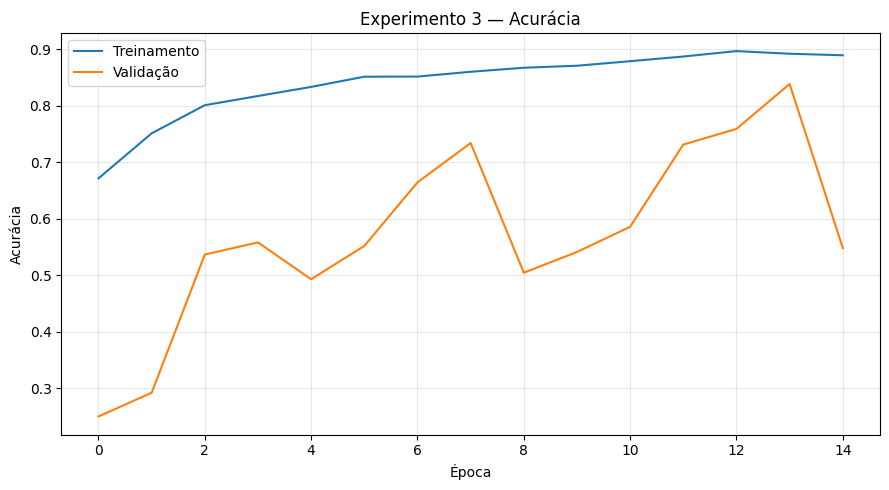

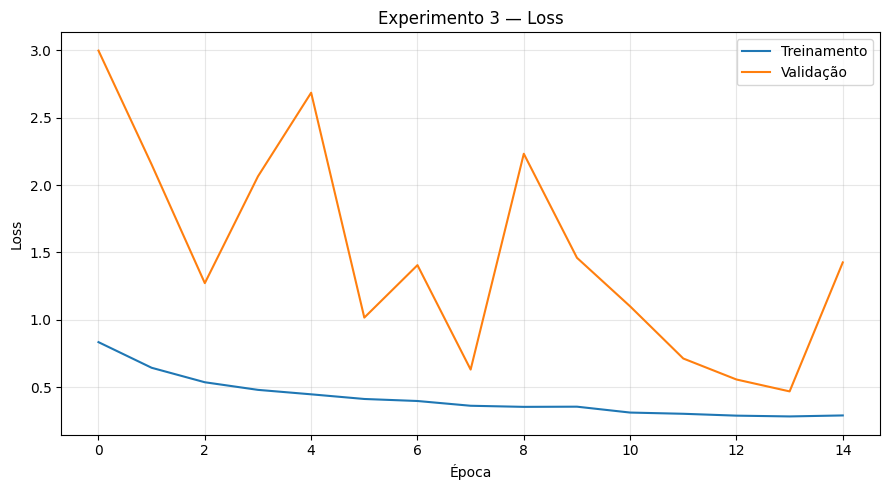

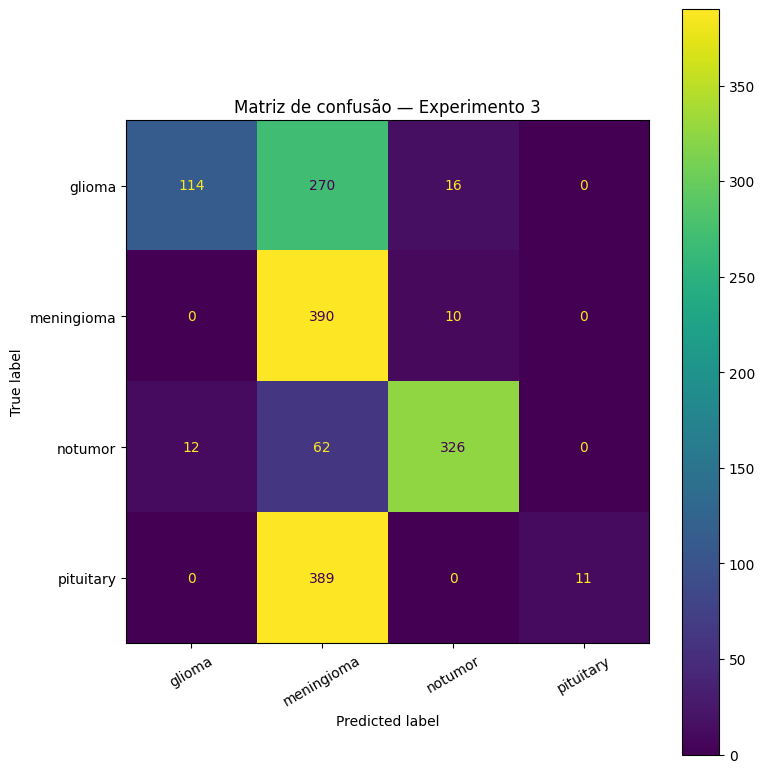

Acurácia:          0.5256
Precisão macro:    0.7955
Recall macro:      0.5256
F1-Score macro:    0.4676

Precisão weighted: 0.7955
Recall weighted:   0.5256
F1 weighted:       0.4676

Tumores classificados como 'notumor': 26
Tempo de treinamento: 1.87 minutos


In [ ]:
def construir_cnn_experimento_3():
    entradas = tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    x = tf.keras.layers.Rescaling(
        1.0 / 255
    )(entradas)

    for filtros in [32, 64, 128]:
        x = tf.keras.layers.Conv2D(
            filtros,
            kernel_size=3,
            padding="same",
            use_bias=False,
        )(x)

        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        128,
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.50)(x)

    saidas = tf.keras.layers.Dense(
        len(CLASSES),
        activation="softmax",
        dtype="float32",
    )(x)

    return tf.keras.Model(
        entradas,
        saidas,
        name="cnn_batchnorm_dropout",
    )


modelo_exp_3 = executar_experimento_cnn(
    experimento=3,
    nome="CNN BatchNorm e Dropout 50%",
    configuracao=(
        "Batch Normalization após convoluções "
        "e Dense; Dropout 0.50"
    ),
    construir_modelo=construir_cnn_experimento_3,
    epochs=5 if FAST_MODE else CNN_EPOCHS,
)

# Experimento 4 — CNN com Data Augmentation, L2 e Early Stopping

Variações:

- rotações pequenas;
- zoom;
- translação;
- contraste;
- espelhamento horizontal;
- regularização L2;
- Early Stopping;
- redução automática da taxa de aprendizado.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.4257 - loss: 1.2219 - val_accuracy: 0.3643 - val_loss: 1.3522 - learning_rate: 0.0010
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.6033 - loss: 0.9827 - val_accuracy: 0.3411 - val_loss: 1.8385 - learning_rate: 0.0010
Epoch 3/25
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6430 - loss: 0.9013
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.6491 - loss: 0.8807 - val_accuracy: 0.3071 - val_loss: 2.1805 - learning_rate: 0.0010
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6824 - loss: 0.7899 - val_accuracy: 0.2937 - val_loss: 2.4917 - learning_rate: 5.0000e-04
Epoch 5/25
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6899 - loss: 0.7622
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.6993 - 

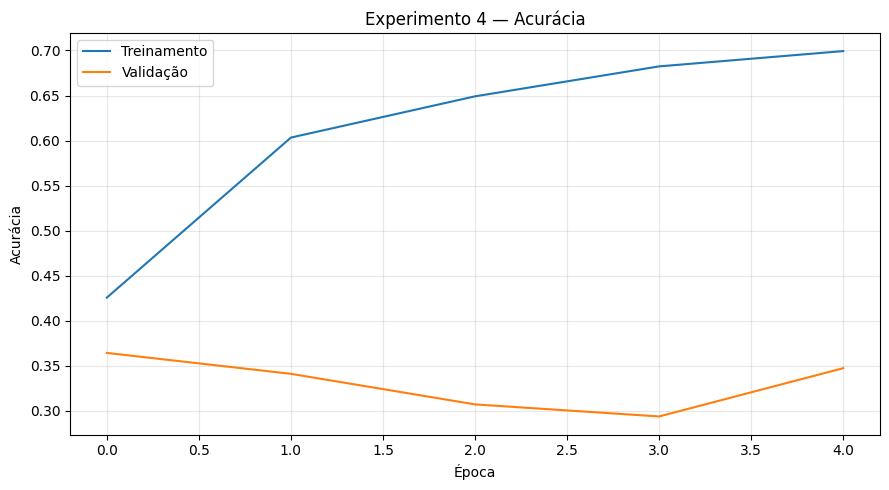

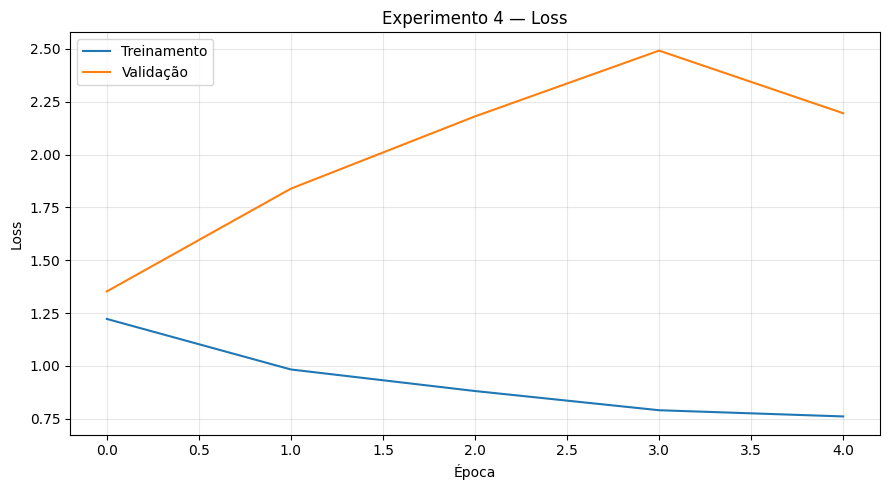

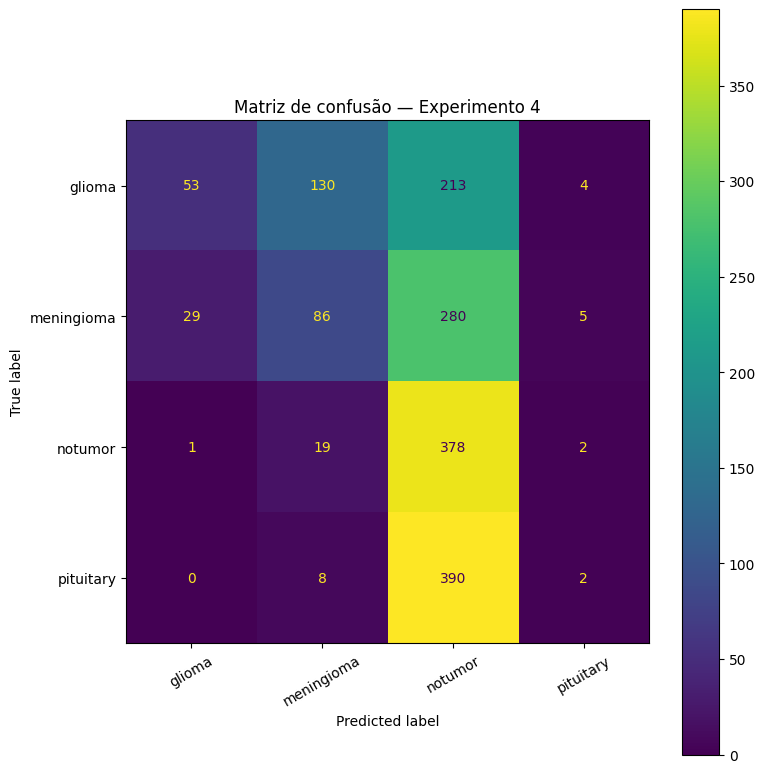

Acurácia:          0.3244
Precisão macro:    0.3615
Recall macro:      0.3244
F1-Score macro:    0.2379

Precisão weighted: 0.3615
Recall weighted:   0.3244
F1 weighted:       0.2379

Tumores classificados como 'notumor': 883
Tempo de treinamento: 0.76 minutos


In [ ]:
def construir_cnn_experimento_4():
    regularizador = tf.keras.regularizers.l2(
        1e-4
    )

    aumento_dados = tf.keras.Sequential([
        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
        ),
        tf.keras.layers.RandomContrast(0.10),
    ], name="data_augmentation")

    return tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        ),

        aumento_dados,

        tf.keras.layers.Rescaling(1.0 / 255),

        tf.keras.layers.Conv2D(
            32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizador,
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            64,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizador,
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizador,
        ),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizador,
        ),

        tf.keras.layers.Dense(
            len(CLASSES),
            activation="softmax",
            dtype="float32",
        ),
    ])


callbacks_exp_4 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

modelo_exp_4 = executar_experimento_cnn(
    experimento=4,
    nome="CNN Augmentation L2 EarlyStopping",
    configuracao=(
        "Data augmentation; L2=1e-4; "
        "EarlyStopping; ReduceLROnPlateau"
    ),
    construir_modelo=construir_cnn_experimento_4,
    epochs=6 if FAST_MODE else CNN_EXP4_MAX_EPOCHS,
    callbacks=callbacks_exp_4,
)

# Preparação das características HOG para os SVMs

Os SVMs não recebem diretamente tensores de imagem no formato usado pelas CNNs.

Cada imagem será:

1. convertida para escala de cinza;
2. redimensionada para 64×64;
3. normalizada;
4. transformada em um vetor HOG.

O HOG descreve orientações de bordas e formas, reduzindo muito a dimensionalidade em comparação ao uso dos pixels RGB achatados.

## 12. Funções para extração HOG

In [ ]:
def extrair_hog_imagem(caminho: str) -> np.ndarray:
    with Image.open(caminho) as imagem:
        imagem = imagem.convert("L")
        imagem = imagem.resize(
            SVM_IMG_SIZE,
            Image.Resampling.BILINEAR,
        )

        matriz = np.asarray(
            imagem,
            dtype=np.float32,
        ) / 255.0

    caracteristicas = hog(
        matriz,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True,
    )

    return caracteristicas.astype(np.float32)


def extrair_hog_dataframe(
    dataframe: pd.DataFrame,
    descricao: str,
):
    vetores = []

    for caminho in tqdm(
        dataframe["path"],
        desc=descricao,
    ):
        vetores.append(
            extrair_hog_imagem(caminho)
        )

    X = np.stack(
        vetores
    ).astype(np.float32)

    y = dataframe[
        "label"
    ].to_numpy(
        dtype=np.int32
    )

    return X, y

## 13. Extração e cache das características

O arquivo de cache evita repetir a extração HOG caso as células dos SVMs sejam executadas novamente na mesma sessão.

In [ ]:
CACHE_HOG = (
    RESULTS_DIR
    / "hog_features_64x64.npz"
)

if CACHE_HOG.exists():
    print("Carregando características HOG do cache...")

    cache = np.load(CACHE_HOG)

    X_train_hog = cache["X_train"]
    y_train_hog = cache["y_train"]

    X_val_hog = cache["X_val"]
    y_val_hog = cache["y_val"]

    X_test_hog = cache["X_test"]
    y_test_hog = cache["y_test"]

else:
    X_train_hog, y_train_hog = extrair_hog_dataframe(
        train_df,
        "HOG — treinamento",
    )

    X_val_hog, y_val_hog = extrair_hog_dataframe(
        val_df,
        "HOG — validação",
    )

    X_test_hog, y_test_hog = extrair_hog_dataframe(
        test_df,
        "HOG — teste",
    )

    np.savez_compressed(
        CACHE_HOG,
        X_train=X_train_hog,
        y_train=y_train_hog,
        X_val=X_val_hog,
        y_val=y_val_hog,
        X_test=X_test_hog,
        y_test=y_test_hog,
    )

print("X_train_hog:", X_train_hog.shape)
print("X_val_hog:", X_val_hog.shape)
print("X_test_hog:", X_test_hog.shape)

HOG — treinamento:   0%|          | 0/4480 [00:00<?, ?it/s]

HOG — validação:   0%|          | 0/1120 [00:00<?, ?it/s]

HOG — teste:   0%|          | 0/1600 [00:00<?, ?it/s]

X_train_hog: (4480, 1764)
X_val_hog: (1120, 1764)
X_test_hog: (1600, 1764)


## 14. Função de execução dos SVMs

In [ ]:
def executar_experimento_svm(
    experimento: int,
    nome: str,
    configuracao: str,
    pipeline,
):
    gc.collect()

    print("Treinando:", nome)

    inicio = time.time()

    pipeline.fit(
        X_train_hog,
        y_train_hog,
    )

    tempo_segundos = time.time() - inicio

    y_val_predito = pipeline.predict(
        X_val_hog
    )

    y_test_predito = pipeline.predict(
        X_test_hog
    )

    val_accuracy = accuracy_score(
        y_val_hog,
        y_val_predito,
    )

    metricas, relatorio_df, matriz = calcular_metricas(
        y_test_hog,
        y_test_predito,
    )

    registro = {
        "experimento": experimento,
        "tecnica": "SVM",
        "modelo": nome,
        "configuracao": configuracao,
        "val_accuracy": val_accuracy,
        "val_loss": np.nan,
        "test_loss": np.nan,
        **metricas,
        "tempo_segundos": tempo_segundos,
        "epocas_executadas": np.nan,
    }

    registrar_resultado(registro)

    relatorios_por_experimento[
        experimento
    ] = relatorio_df

    matrizes_por_experimento[
        experimento
    ] = matriz

    relatorio_df.to_csv(
        REPORTS_DIR
        / f"experimento_{experimento:02d}.csv",
        index=False,
    )

    joblib.dump(
        pipeline,
        MODELS_DIR
        / (
            f"experimento_{experimento:02d}_"
            f"{nome_seguro(nome)}.joblib"
        ),
    )

    salvar_matriz_confusao(
        matriz,
        experimento,
        f"Matriz de confusão — Experimento {experimento}",
    )

    exibir_metricas(metricas)

    print(
        f"Acurácia de validação: "
        f"{val_accuracy:.4f}"
    )

    print(
        f"Tempo de treinamento: "
        f"{tempo_segundos / 60:.2f} minutos"
    )

    return pipeline

# Experimento 5 — SVM com kernel linear e C=1

Treinando: SVM Linear C=1


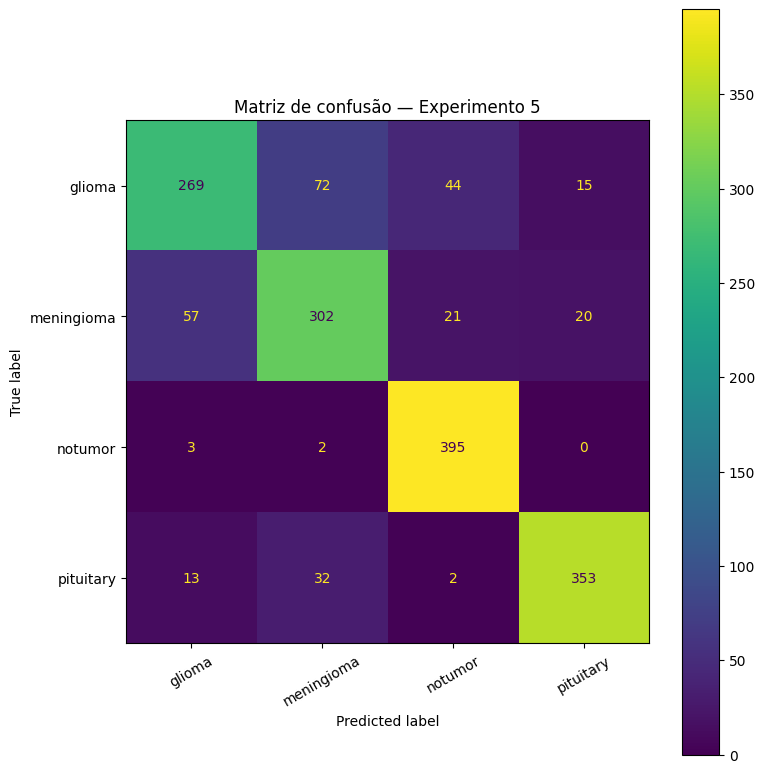

Acurácia:          0.8244
Precisão macro:    0.8229
Recall macro:      0.8244
F1-Score macro:    0.8213

Precisão weighted: 0.8229
Recall weighted:   0.8244
F1 weighted:       0.8213

Tumores classificados como 'notumor': 67
Acurácia de validação: 0.8589
Tempo de treinamento: 0.11 minutos


In [ ]:
pipeline_exp_5 = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "svm",
        SVC(
            kernel="linear",
            C=1,
            cache_size=1500,
        ),
    ),
])

modelo_exp_5 = executar_experimento_svm(
    experimento=5,
    nome="SVM Linear C=1",
    configuracao=(
        "HOG 64x64; StandardScaler; "
        "kernel linear; C=1"
    ),
    pipeline=pipeline_exp_5,
)

# Experimento 6 — SVM com kernel RBF, C=1 e gamma="scale"

Treinando: SVM RBF C=1


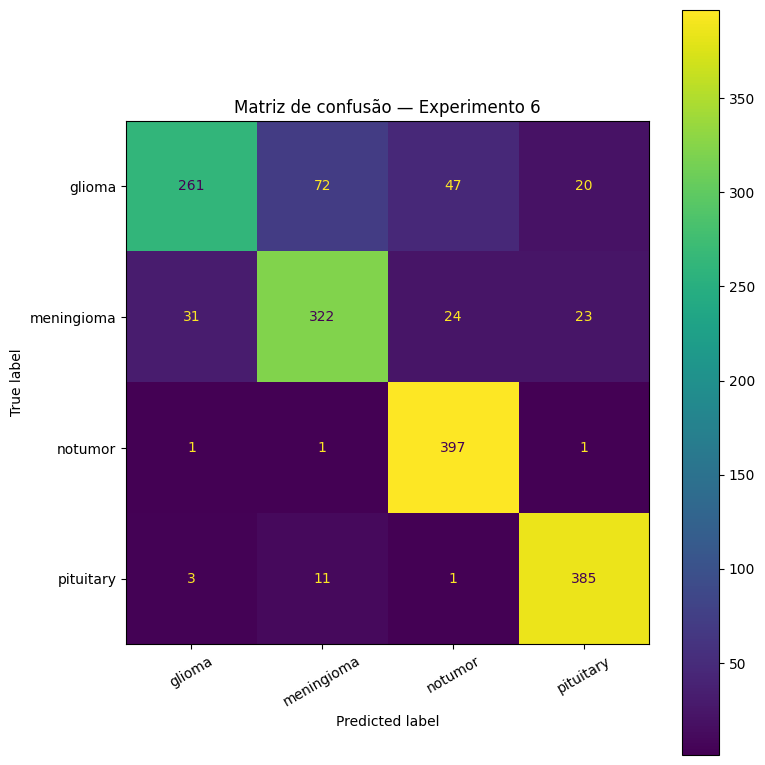

Acurácia:          0.8531
Precisão macro:    0.8547
Recall macro:      0.8531
F1-Score macro:    0.8479

Precisão weighted: 0.8547
Recall weighted:   0.8531
F1 weighted:       0.8479

Tumores classificados como 'notumor': 72
Acurácia de validação: 0.9054
Tempo de treinamento: 0.18 minutos


In [ ]:
pipeline_exp_6 = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
            cache_size=1500,
        ),
    ),
])

modelo_exp_6 = executar_experimento_svm(
    experimento=6,
    nome="SVM RBF C=1",
    configuracao=(
        "HOG 64x64; StandardScaler; "
        "kernel RBF; C=1; gamma=scale"
    ),
    pipeline=pipeline_exp_6,
)

# Experimento 7 — SVM com kernel RBF e C=10

O valor maior de `C` aplica uma penalização mais forte aos erros de classificação no treinamento.

Treinando: SVM RBF C=10


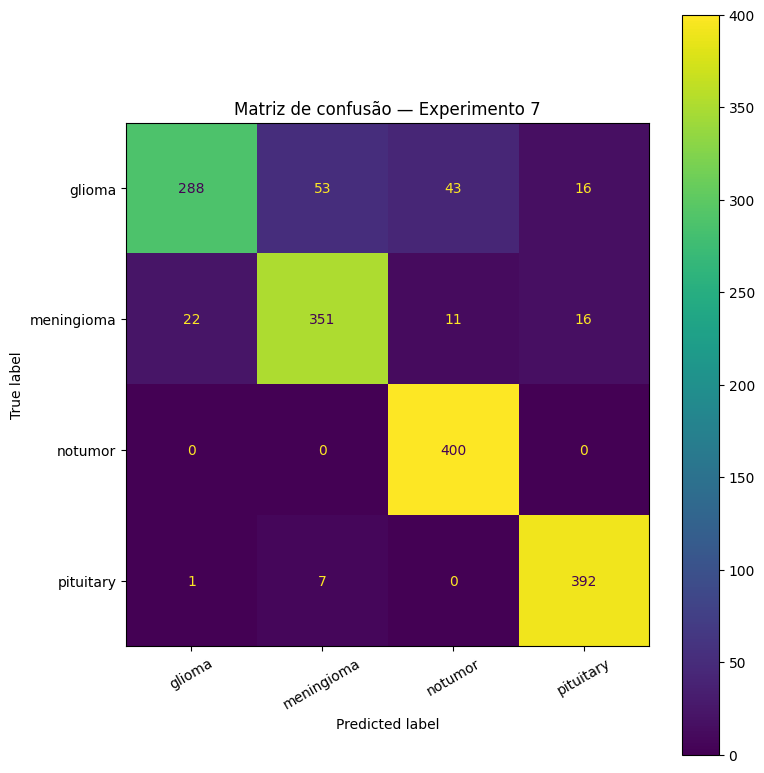

Acurácia:          0.8944
Precisão macro:    0.8964
Recall macro:      0.8944
F1-Score macro:    0.8910

Precisão weighted: 0.8964
Recall weighted:   0.8944
F1 weighted:       0.8910

Tumores classificados como 'notumor': 54
Acurácia de validação: 0.9366
Tempo de treinamento: 0.21 minutos


In [ ]:
pipeline_exp_7 = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            cache_size=1500,
        ),
    ),
])

modelo_exp_7 = executar_experimento_svm(
    experimento=7,
    nome="SVM RBF C=10",
    configuracao=(
        "HOG 64x64; StandardScaler; "
        "kernel RBF; C=10; gamma=scale"
    ),
    pipeline=pipeline_exp_7,
)

# Experimento 8 — SVM RBF com PCA e balanceamento

Variações:

- redução de dimensionalidade para até 256 componentes;
- kernel RBF;
- `C=10`;
- `class_weight="balanced"`.

Treinando: SVM RBF PCA Balanceado


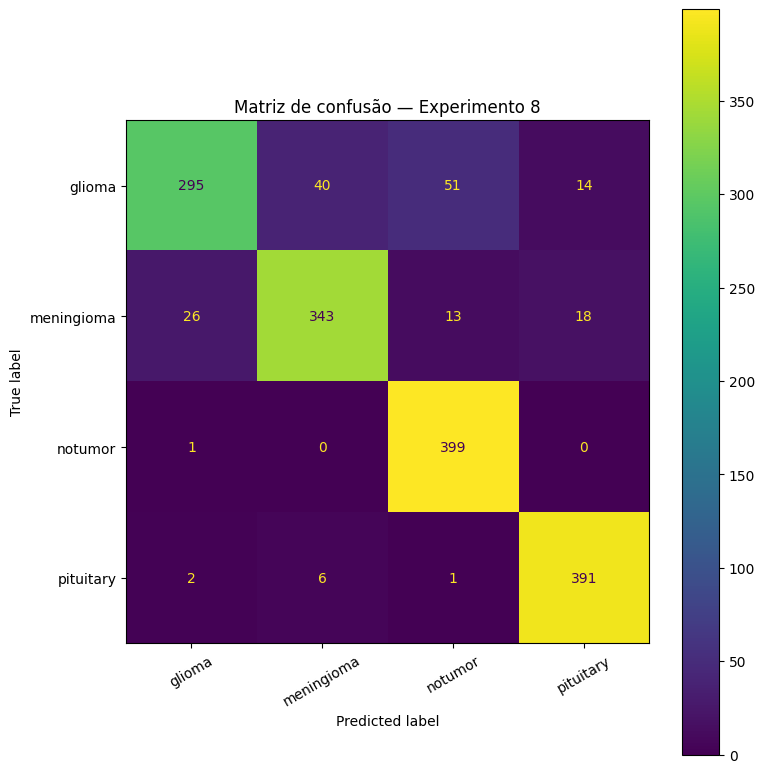

Acurácia:          0.8925
Precisão macro:    0.8941
Recall macro:      0.8925
F1-Score macro:    0.8895

Precisão weighted: 0.8941
Recall weighted:   0.8925
F1 weighted:       0.8895

Tumores classificados como 'notumor': 65
Acurácia de validação: 0.9411
Tempo de treinamento: 0.06 minutos


In [ ]:
numero_componentes_pca = min(
    256,
    X_train_hog.shape[1],
    X_train_hog.shape[0] - 1,
)

pipeline_exp_8 = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "pca",
        PCA(
            n_components=numero_componentes_pca,
            svd_solver="randomized",
            random_state=SEED,
        ),
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            cache_size=1500,
        ),
    ),
])

modelo_exp_8 = executar_experimento_svm(
    experimento=8,
    nome="SVM RBF PCA Balanceado",
    configuracao=(
        f"HOG 64x64; PCA {numero_componentes_pca}; "
        "RBF; C=10; class_weight=balanced"
    ),
    pipeline=pipeline_exp_8,
)

# Comparação final dos oito experimentos

## 15. Tabela completa de resultados

In [ ]:
resultados_df = pd.DataFrame(
    resultados
).sort_values(
    "experimento"
).reset_index(
    drop=True
)

colunas_principais = [
    "experimento",
    "tecnica",
    "modelo",
    "val_accuracy",
    "acuracia",
    "precisao_macro",
    "recall_macro",
    "f1_macro",
    "precisao_weighted",
    "recall_weighted",
    "f1_weighted",
    "tumores_como_notumor",
    "tempo_segundos",
]

display(
    resultados_df[
        colunas_principais
    ].style.format({
        "val_accuracy": "{:.4f}",
        "acuracia": "{:.4f}",
        "precisao_macro": "{:.4f}",
        "recall_macro": "{:.4f}",
        "f1_macro": "{:.4f}",
        "precisao_weighted": "{:.4f}",
        "recall_weighted": "{:.4f}",
        "f1_weighted": "{:.4f}",
        "tempo_segundos": "{:.2f}",
    })
)

resultados_df.to_csv(
    RESULTS_DIR / "resultados_8_experimentos.csv",
    index=False,
)

,experimento,tecnica,modelo,val_accuracy,acuracia,precisao_macro,recall_macro,f1_macro,precisao_weighted,recall_weighted,f1_weighted,tumores_como_notumor,tempo_segundos
0,1,CNN,CNN básica,0.8330,0.7194,0.7221,0.7194,0.7009,0.7221,0.7194,0.7009,214,128.80
1,2,CNN,CNN com Dropout 20%,0.8188,0.7094,0.7319,0.7094,0.7064,0.7319,0.7094,0.7064,88,118.98
2,3,CNN,CNN BatchNorm e Dropout 50%,0.8384,0.5256,0.7955,0.5256,0.4676,0.7955,0.5256,0.4676,26,112.44
3,4,CNN,CNN Augmentation L2 EarlyStopping,0.3643,0.3244,0.3615,0.3244,0.2379,0.3615,0.3244,0.2379,883,45.55
4,5,SVM,SVM Linear C=1,0.8589,0.8244,0.8229,0.8244,0.8213,0.8229,0.8244,0.8213,67,6.43
5,6,SVM,SVM RBF C=1,0.9054,0.8531,0.8547,0.8531,0.8479,0.8547,0.8531,0.8479,72,10.81
6,7,SVM,SVM RBF C=10,0.9366,0.8944,0.8964,0.8944,0.8910,0.8964,0.8944,0.8910,54,12.49
7,8,SVM,SVM RBF PCA Balanceado,0.9411,0.8925,0.8941,0.8925,0.8895,0.8941,0.8925,0.8895,65,3.47


## 16. Gráfico comparativo das métricas

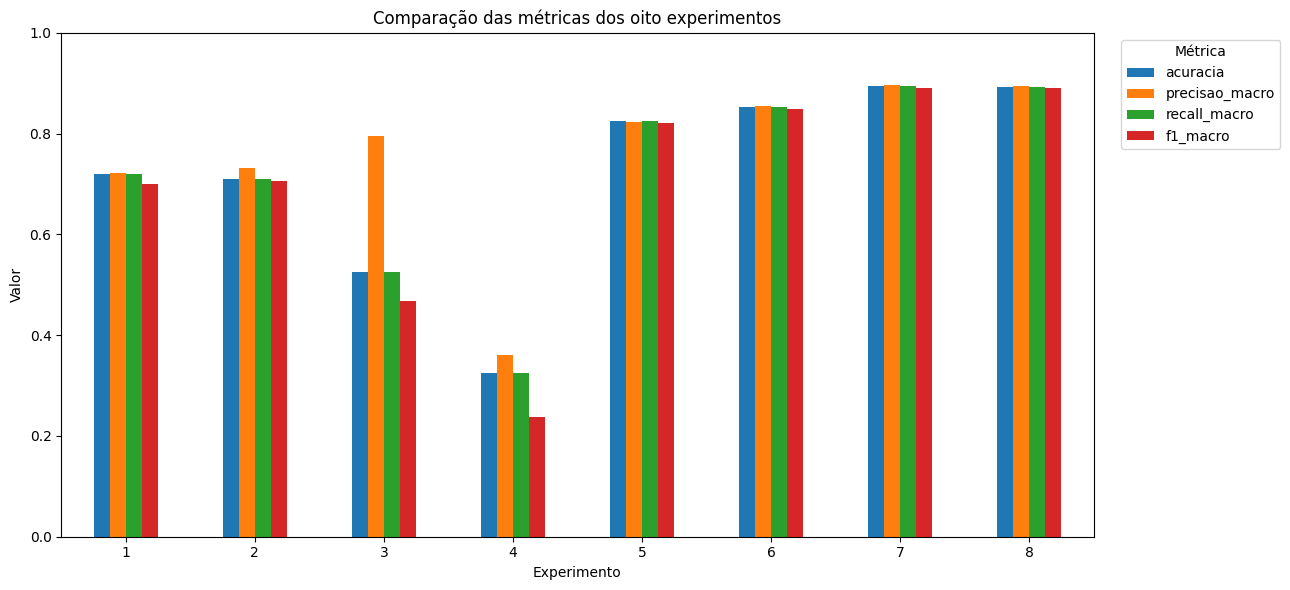

In [ ]:
metricas_grafico = resultados_df.set_index(
    "experimento"
)[
    [
        "acuracia",
        "precisao_macro",
        "recall_macro",
        "f1_macro",
    ]
]

metricas_grafico.plot(
    kind="bar",
    figsize=(13, 6),
)

plt.title(
    "Comparação das métricas dos oito experimentos"
)
plt.xlabel("Experimento")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

## 17. Melhor abordagem pelo F1-Score macro

In [ ]:
indice_melhor = resultados_df[
    "f1_macro"
].idxmax()

melhor = resultados_df.loc[
    indice_melhor
]

melhor_experimento = int(
    melhor["experimento"]
)

print("Melhor abordagem:")
print("Experimento:", melhor_experimento)
print("Técnica:", melhor["tecnica"])
print("Modelo:", melhor["modelo"])
print(f"Acurácia: {melhor['acuracia']:.4f}")
print(f"Precisão macro: {melhor['precisao_macro']:.4f}")
print(f"Recall macro: {melhor['recall_macro']:.4f}")
print(f"F1 macro: {melhor['f1_macro']:.4f}")
print(
    "Tumores classificados como 'notumor':",
    int(melhor["tumores_como_notumor"]),
)

print("\nRelatório por classe do melhor experimento:")
display(
    relatorios_por_experimento[
        melhor_experimento
    ]
)

Melhor abordagem:
Experimento: 7
Técnica: SVM
Modelo: SVM RBF C=10
Acurácia: 0.8944
Precisão macro: 0.8964
Recall macro: 0.8944
F1 macro: 0.8910
Tumores classificados como 'notumor': 54

Relatório por classe do melhor experimento:


,classe,precision,recall,f1-score,support
0,glioma,0.926045,0.720000,0.810127,400.000000
1,meningioma,0.854015,0.877500,0.865598,400.000000
2,notumor,0.881057,1.000000,0.936768,400.000000
3,pituitary,0.924528,0.980000,0.951456,400.000000
4,accuracy,0.894375,0.894375,0.894375,0.894375
5,macro avg,0.896411,0.894375,0.890987,1600.000000
6,weighted avg,0.896411,0.894375,0.890987,1600.000000


## 18. Melhor abordagem considerando falsos negativos críticos

Esta análise procura primeiro o menor número de tumores classificados como `notumor`. Em caso de empate, escolhe o maior F1 macro.

In [ ]:
melhor_seguranca = (
    resultados_df
    .sort_values(
        [
            "tumores_como_notumor",
            "f1_macro",
        ],
        ascending=[True, False],
    )
    .iloc[0]
)

print(
    "Melhor resultado pelo critério de segurança:"
)
print(
    "Experimento:",
    int(melhor_seguranca["experimento"]),
)
print(
    "Modelo:",
    melhor_seguranca["modelo"],
)
print(
    "Tumores classificados como 'notumor':",
    int(melhor_seguranca["tumores_como_notumor"]),
)
print(
    f"F1 macro: "
    f"{melhor_seguranca['f1_macro']:.4f}"
)

Melhor resultado pelo critério de segurança:
Experimento: 3
Modelo: CNN BatchNorm e Dropout 50%
Tumores classificados como 'notumor': 26
F1 macro: 0.4676


## 19. Comparação de tempo de treinamento

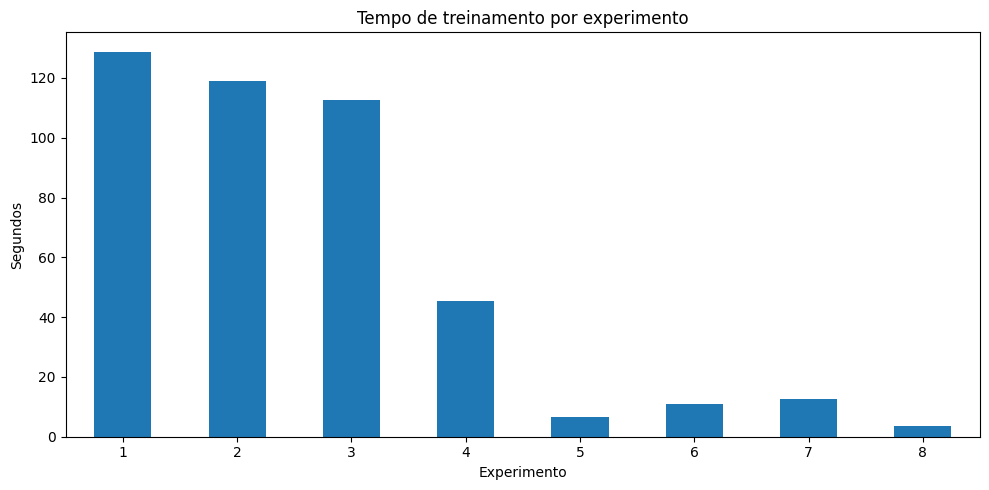

In [ ]:
resultados_df.plot(
    x="experimento",
    y="tempo_segundos",
    kind="bar",
    figsize=(10, 5),
    legend=False,
)

plt.title("Tempo de treinamento por experimento")
plt.xlabel("Experimento")
plt.ylabel("Segundos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Texto-base para a análise do relatório

Utilize os resultados efetivamente produzidos pelo notebook para completar a análise:

1. Identifique o modelo com maior F1 macro.
2. Compare esse modelo com o de maior acurácia.
3. Observe o recall individual de `glioma`, `meningioma` e `pituitary`.
4. Analise quantos tumores foram classificados como `notumor`.
5. Compare as curvas de treinamento e validação das CNNs.
6. Verifique se Dropout, Batch Normalization, L2 e data augmentation reduziram overfitting.
7. Compare o kernel linear com o RBF.
8. Avalie o impacto do aumento de `C`.
9. Avalie se PCA e balanceamento melhoraram o desempenho ou reduziram o tempo.

## 20. Geração automática de um resumo

In [ ]:
melhor_f1 = resultados_df.loc[
    resultados_df["f1_macro"].idxmax()
]

melhor_acuracia = resultados_df.loc[
    resultados_df["acuracia"].idxmax()
]

menor_falso_negativo = resultados_df.sort_values(
    [
        "tumores_como_notumor",
        "f1_macro",
    ],
    ascending=[True, False],
).iloc[0]

resumo = f'''
RESUMO DOS EXPERIMENTOS

O experimento com maior F1-Score macro foi o
Experimento {int(melhor_f1["experimento"])} —
{melhor_f1["modelo"]}, com F1 macro de
{melhor_f1["f1_macro"]:.4f}.

O maior valor de acurácia foi obtido pelo
Experimento {int(melhor_acuracia["experimento"])} —
{melhor_acuracia["modelo"]}, com acurácia de
{melhor_acuracia["acuracia"]:.4f}.

O menor número de tumores classificados como
"notumor" foi obtido pelo Experimento
{int(menor_falso_negativo["experimento"])} —
{menor_falso_negativo["modelo"]}, com
{int(menor_falso_negativo["tumores_como_notumor"])}
ocorrências.

A conclusão final deve considerar simultaneamente
F1 macro, recall das classes de tumor, matriz de
confusão, falsos negativos, overfitting e custo
computacional.
'''.strip()

print(resumo)

(RESULTS_DIR / "resumo_automatico.txt").write_text(
    resumo,
    encoding="utf-8",
)

RESUMO DOS EXPERIMENTOS

O experimento com maior F1-Score macro foi o
Experimento 7 —
SVM RBF C=10, com F1 macro de
0.8910.

O maior valor de acurácia foi obtido pelo
Experimento 7 —
SVM RBF C=10, com acurácia de
0.8944.

O menor número de tumores classificados como
"notumor" foi obtido pelo Experimento
3 —
CNN BatchNorm e Dropout 50%, com
26
ocorrências.

A conclusão final deve considerar simultaneamente
F1 macro, recall das classes de tumor, matriz de
confusão, falsos negativos, overfitting e custo
computacional.


520

# Salvamento final

Todos os arquivos são mantidos em `/content/brain_tumor_results`.

A célula seguinte compacta:

- modelos;
- métricas;
- relatórios;
- matrizes de confusão;
- históricos de treinamento;
- características HOG.

In [ ]:
arquivo_zip = shutil.make_archive(
    base_name="/content/brain_tumor_results",
    format="zip",
    root_dir=RESULTS_DIR,
)

print("Arquivo compactado:")
print(arquivo_zip)

Arquivo compactado:
/content/brain_tumor_results.zip


## 21. Download opcional dos resultados

A execução da próxima célula inicia o download do arquivo ZIP no navegador.

In [ ]:
from google.colab import files

files.download(
    "/content/brain_tumor_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 22. Salvamento opcional no Google Drive

Execute somente caso queira manter os resultados no Drive após o encerramento da sessão.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
DESTINO_DRIVE = Path(
    "/content/drive/MyDrive/"
    "brain-tumor-mri-classification"
)

DESTINO_DRIVE.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copy2(
    "/content/brain_tumor_results.zip",
    DESTINO_DRIVE / "brain_tumor_results.zip",
)

resultados_df.to_csv(
    DESTINO_DRIVE / "resultados_8_experimentos.csv",
    index=False,
)

print("Resultados salvos em:")
print(DESTINO_DRIVE)

Resultados salvos em:
/content/drive/MyDrive/brain-tumor-mri-classification


# Checklist atendido

- [x] Oito experimentos;
- [x] Duas técnicas: CNN e SVM;
- [x] Variação de parâmetros;
- [x] Dropout;
- [x] Batch Normalization;
- [x] Data augmentation;
- [x] Regularização L2;
- [x] Early Stopping;
- [x] Kernels linear e RBF;
- [x] Variação de `C`;
- [x] PCA;
- [x] Balanceamento de classes;
- [x] Acurácia;
- [x] Precisão;
- [x] Recall;
- [x] F1-Score;
- [x] Matrizes de confusão;
- [x] Tabela final;
- [x] Identificação automática da melhor abordagem.